# Synthetic Cryo-ET Data Generation from VTK Ground Truth
- Input: `data/synthetic/gt/relaxed_***.vtk`
- Output: `data/synthetic/mrc/`

In [1]:
import sys
from pathlib import Path

# Get the absolute path of the project root (one level above notebooks/)
project_root = Path().resolve().parent

# Add "src/" to sys.path
sys.path.append(str(project_root / "src"))

In [8]:
## To reload

import importlib
import data_generation.mesh_to_cryoet as mesh_to_cryoet

importlib.reload(mesh_to_cryoet)

<module 'data_generation.mesh_to_cryoet' from '/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/src/data_generation/mesh_to_cryoet.py'>

Pseudo cryo-ET data saved to: ../data/synthetic/mrc/biconcave_a010_m04_wz60.mrc


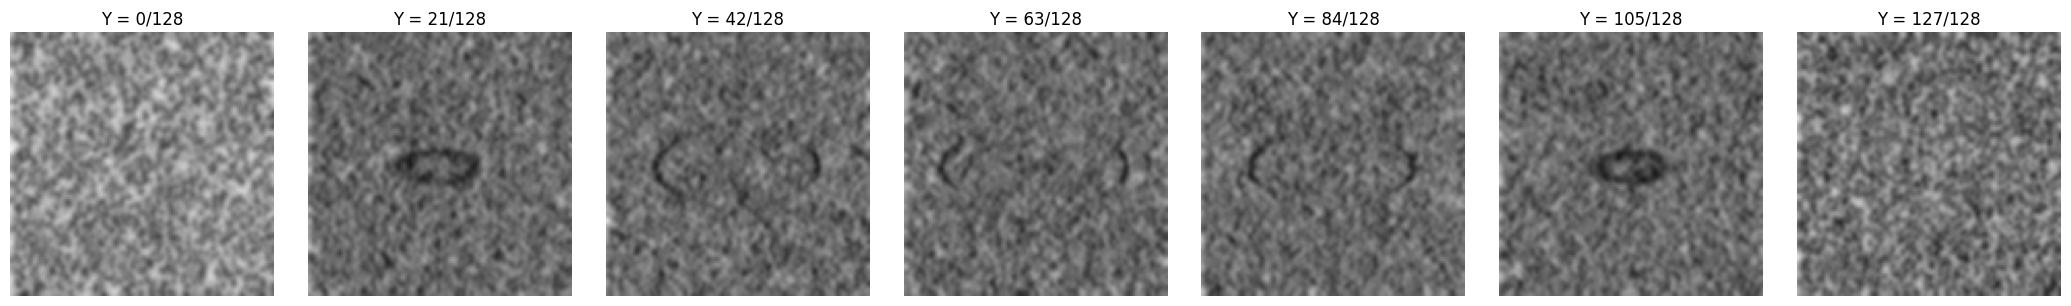

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from data_generation.mesh_to_cryoet import generate_cryoet_from_vtk, plot_multiple_slices

#### Parameters ####
shape="biconcave"
sigma=1
additive=0.1
missing=0.4
grid_size = 128
wedge_angle = 60

if shape == "biconcave":
    margin_ratio = 0.4
elif shape == "bud_04":
    margin_ratio = 0.0

str_add = f"{additive:.2f}".replace('.', '')
str_miss = f"{missing:.1f}".replace('.', '')

input_file = f"../data/synthetic/gt/relaxed_{shape}.vtk"
output_file = None
# output_file = f"../data/synthetic/mrc/{shape}_a{str_add}_m{str_miss}.mrc"
output_file = f"../data/synthetic/mrc/{shape}_a{str_add}_m{str_miss}_wz{wedge_angle}.mrc"

#### Generate pseudo cryo-ET volume ####
pseudo_cryoET = generate_cryoet_from_vtk(
    input_file, output_file, grid_size=grid_size, sigma=sigma, 
    additive_noise=additive, missing_ratio=missing, margin_ratio=margin_ratio,
    missing_wedge=True, wedge_axis="z", tilt_max=wedge_angle
)

#### Visualize data ####
thre = None
# thre = 0.78
num_slices = 7

pseudo_cryoET = (pseudo_cryoET - np.min(pseudo_cryoET)) / (np.max(pseudo_cryoET) - np.min(pseudo_cryoET))
# plot_multiple_slices(pseudo_cryoET, axis='x', num_slices=num_slices, thre=thre)
plot_multiple_slices(pseudo_cryoET, axis='y', num_slices=num_slices, thre=thre)
